# IEEE Xplore foundation/agentic robotic-hand review

The dashboard below visualizes every deduplicated record returned by the crawler. Citation counts are descriptive only; uncited recent papers are retained so the notebook remains useful for a state-of-the-art review.

**Coverage:** 2019–2026 · **Source:** IEEE Xplore · **Query family:** robotic-hand embodiment or manipulation, combined with foundation-model or agentic terminology.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_dir = Path("data_foundation_agentic")
if not data_dir.is_dir():
    data_dir = Path("crawlers/IEEE-Xplore-API_p3/data_foundation_agentic")

files = sorted(
    data_dir.glob("data_*.json"),
    key=lambda path: int(path.stem.split("_")[-1]),
)
if not files:
    raise FileNotFoundError(f"No IEEE result files found in {data_dir.resolve()}")

all_articles_raw = []
for path in files:
    with path.open(encoding="utf-8") as file:
        response = json.load(file)
    all_articles_raw.extend(response.get("articles", []))

# IEEE article_number is the stable identifier. Deduplicate overlapping pages
# while retaining the first occurrence and falling back to title if needed.
articles_by_id = {}
for article in all_articles_raw:
    identifier = article.get("article_number") or article.get("title")
    articles_by_id.setdefault(str(identifier), article)
all_articles = list(articles_by_id.values())

print(f"Loaded {len(files)} pages")
print(f"Raw rows: {len(all_articles_raw)}")
print(f"Unique articles: {len(all_articles)}")

Loaded 3 pages
Raw rows: 435
Unique articles: 435


In [2]:
print("Overall Number of Articles: ",len(all_articles))

Overall Number of Articles:  435


In [3]:
keywords_0 = ["hand", "gripper"]
keywords_1 = ["manipulation", "grasping", "grip", "skill"]

keywords_used = []
terms_used = []
articles_filtered = []
articles_filtered_titles = []
missing_index_terms = 0

for article in all_articles:
    try:
        citations = int(article.get("citing_paper_count", 0) or 0)
    except (TypeError, ValueError):
        citations = 0
    if citations <= 0:
        continue

    index_terms = article.get("index_terms")
    if not isinstance(index_terms, dict):
        missing_index_terms += 1
        continue

    all_terms = []
    for term_group in index_terms.values():
        if not isinstance(term_group, dict):
            continue
        all_terms.extend(
            str(term).lower() for term in term_group.get("terms", [])
        )
    all_terms = np.unique(all_terms)

    matched_keywords_0 = [
        keyword for keyword in keywords_0
        if any(keyword in term for term in all_terms)
    ]
    matched_keywords_1 = [
        keyword for keyword in keywords_1
        if any(keyword in term for term in all_terms)
    ]

    if matched_keywords_0 and matched_keywords_1:
        articles_filtered.append(article)
        articles_filtered_titles.append(article.get("title", ""))
        keywords_used.extend(matched_keywords_0 + matched_keywords_1)
        terms_used.extend(all_terms)

terms_used = np.unique(terms_used)
print(f"Skipped {missing_index_terms} cited articles without index terms")

Skipped 87 cited articles without index terms


In [4]:
print("Overall filtered Articles: ",len(articles_filtered))

Overall filtered Articles:  16


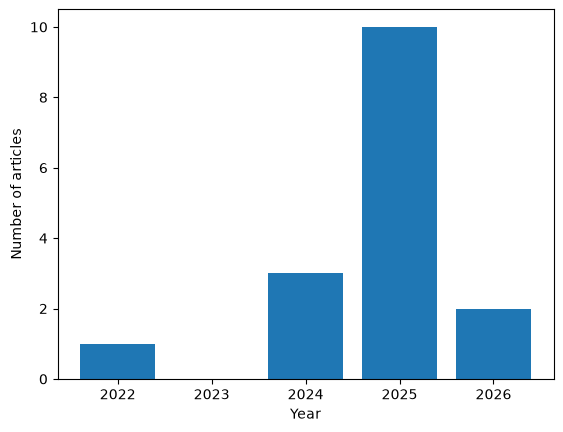

In [5]:
years=[]
for i in articles_filtered:
    years.append(i["publication_year"])
plt.bar(*np.unique(years, return_counts=True))
# set x-axis label
plt.xlabel('Year')
# set y-axis label
plt.ylabel('Number of articles')
plt.show()

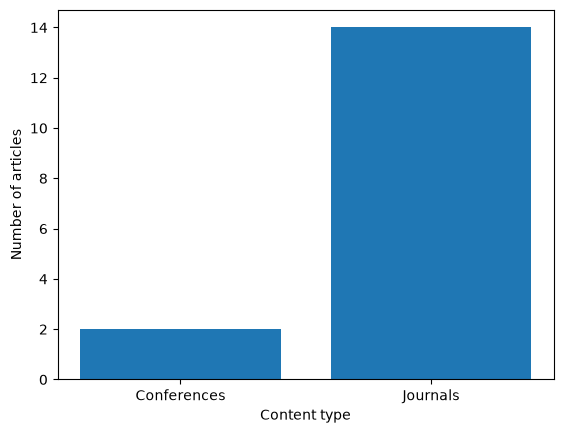

In [6]:
content_type=[]
for i in articles_filtered:
    content_type.append(i["content_type"].split()[0])
plt.bar(*np.unique(content_type, return_counts=True))
# set x-axis label
plt.xlabel('Content type')
# set y-axis label
plt.ylabel('Number of articles')
plt.show()

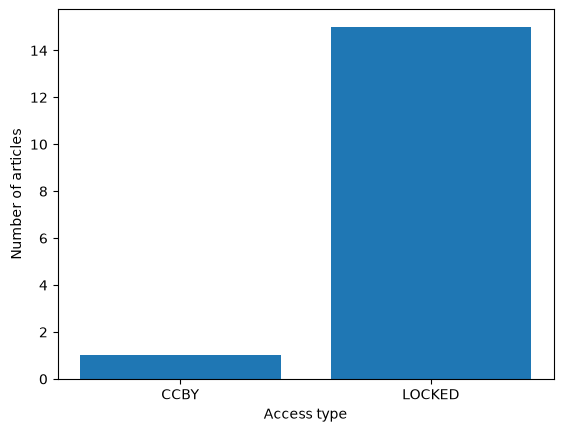

In [7]:
access_type=[]
for i in articles_filtered:
    access_type.append(i["access_type"].split()[0])
plt.bar(*np.unique(access_type, return_counts=True))
# set x-axis label
plt.xlabel('Access type')
# set y-axis label
plt.ylabel('Number of articles')
plt.show()

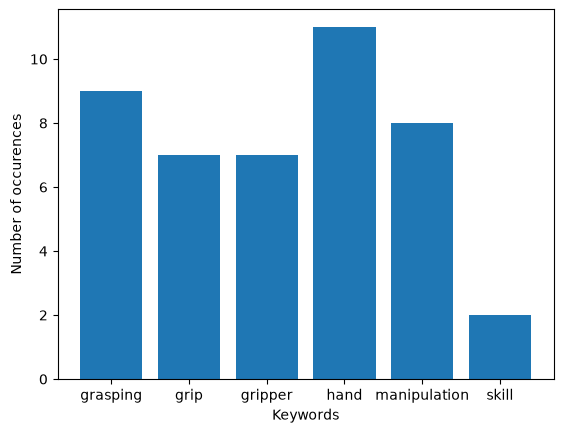

In [8]:
plt.bar(*np.unique(keywords_used, return_counts=True))
# set x-axis label
plt.xlabel('Keywords')
# set y-axis label
plt.ylabel('Number of occurences')
plt.show()

## Exploratory dashboard

These views use the complete deduplicated result set (`all_articles`), not the legacy citation/index-term subset above. Concept matches are transparent title/abstract/keyword heuristics for prioritizing manual screening; they are not automatic inclusion decisions.

In [9]:
from collections import Counter

import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})

viz_df = pd.DataFrame(all_articles).copy()
text_fields = ["title", "abstract", "author_terms", "ieee_terms", "dynamic_index_terms"]
for field in text_fields:
    if field not in viz_df:
        viz_df[field] = ""
    viz_df[field] = viz_df[field].fillna("").astype(str)

viz_df["search_text"] = viz_df[text_fields].agg(" ".join, axis=1).str.lower()
viz_df["year"] = pd.to_numeric(viz_df.get("publication_year"), errors="coerce").astype("Int64")
viz_df["citations"] = pd.to_numeric(viz_df.get("citing_paper_count", 0), errors="coerce").fillna(0)
viz_df["downloads"] = pd.to_numeric(viz_df.get("download_count", 0), errors="coerce").fillna(0)
viz_df["content_group"] = viz_df.get("content_type", "Unknown").fillna("Unknown").astype(str).replace("", "Unknown")
viz_df["access_group"] = viz_df.get("access_type", "Unknown").fillna("Unknown").astype(str).replace("", "Unknown")

concept_terms = {
    "Hand embodiment": [
        "robotic hand", "robot hand", "dexterous hand", "anthropomorphic hand",
        "prosthetic hand", "bionic hand", "multifingered hand", "multi-fingered hand",
        "five-finger hand", "robotic palm", "robotic finger", "hand morphology",
        "finger synergy", "hand synergy", "dexterous grasp", "multifinger grasp",
    ],
    "Manipulation": [
        "grasping", "grasp generation", "functional grasp", "task-oriented grasp",
        "dexterous manipulation", "in-hand manipulation", "in hand manipulation",
        "object manipulation", "hand-object interaction", "finger control", "hand control",
    ],
    "Foundation / multimodal": [
        "foundation model", "large language model", "vision-language model",
        "visual language model", "vision-language-action", "vision language action",
        "multimodal large language model", "generalist policy", "vision-language policy",
        "promptable foundation model", "tactile-language-action", "latent action representation",
    ],
    "Agentic reasoning": [
        "agentic ai", "llm planner", "vlm planner", "multimodal planner",
        "language-guided planning", "open-world planning", "task decomposition",
        "chain-of-thought", "self-evaluation", "self-reflection", "closed-loop reasoning",
        "autonomous reasoning", "reasoning-based manipulation", "failure recovery",
    ],
}

def matching_terms(text, terms):
    return [term for term in terms if term in text]

for concept, terms in concept_terms.items():
    column = concept.lower().replace(" / ", "_").replace(" ", "_")
    viz_df[f"{column}_terms"] = viz_df["search_text"].map(lambda text: matching_terms(text, terms))
    viz_df[column] = viz_df[f"{column}_terms"].map(bool)

viz_df["ai_visible"] = viz_df["foundation_multimodal"] | viz_df["agentic_reasoning"]
viz_df["scope_score"] = (
    viz_df["hand_embodiment"].astype(int)
    + viz_df["manipulation"].astype(int)
    + viz_df["ai_visible"].astype(int)
)
viz_df["screening_priority"] = np.select(
    [viz_df["scope_score"].eq(3), viz_df["scope_score"].eq(2)],
    ["High: all concepts visible", "Medium: two concepts visible"],
    default="Full-text check",
)

print(f"Records visualized: {len(viz_df)}")
print(f"Year range: {viz_df['year'].min()}–{viz_df['year'].max()}")
print(f"Uncited records retained: {(viz_df['citations'] == 0).sum()}")

Records visualized: 435
Year range: 2019–2026
Uncited records retained: 209


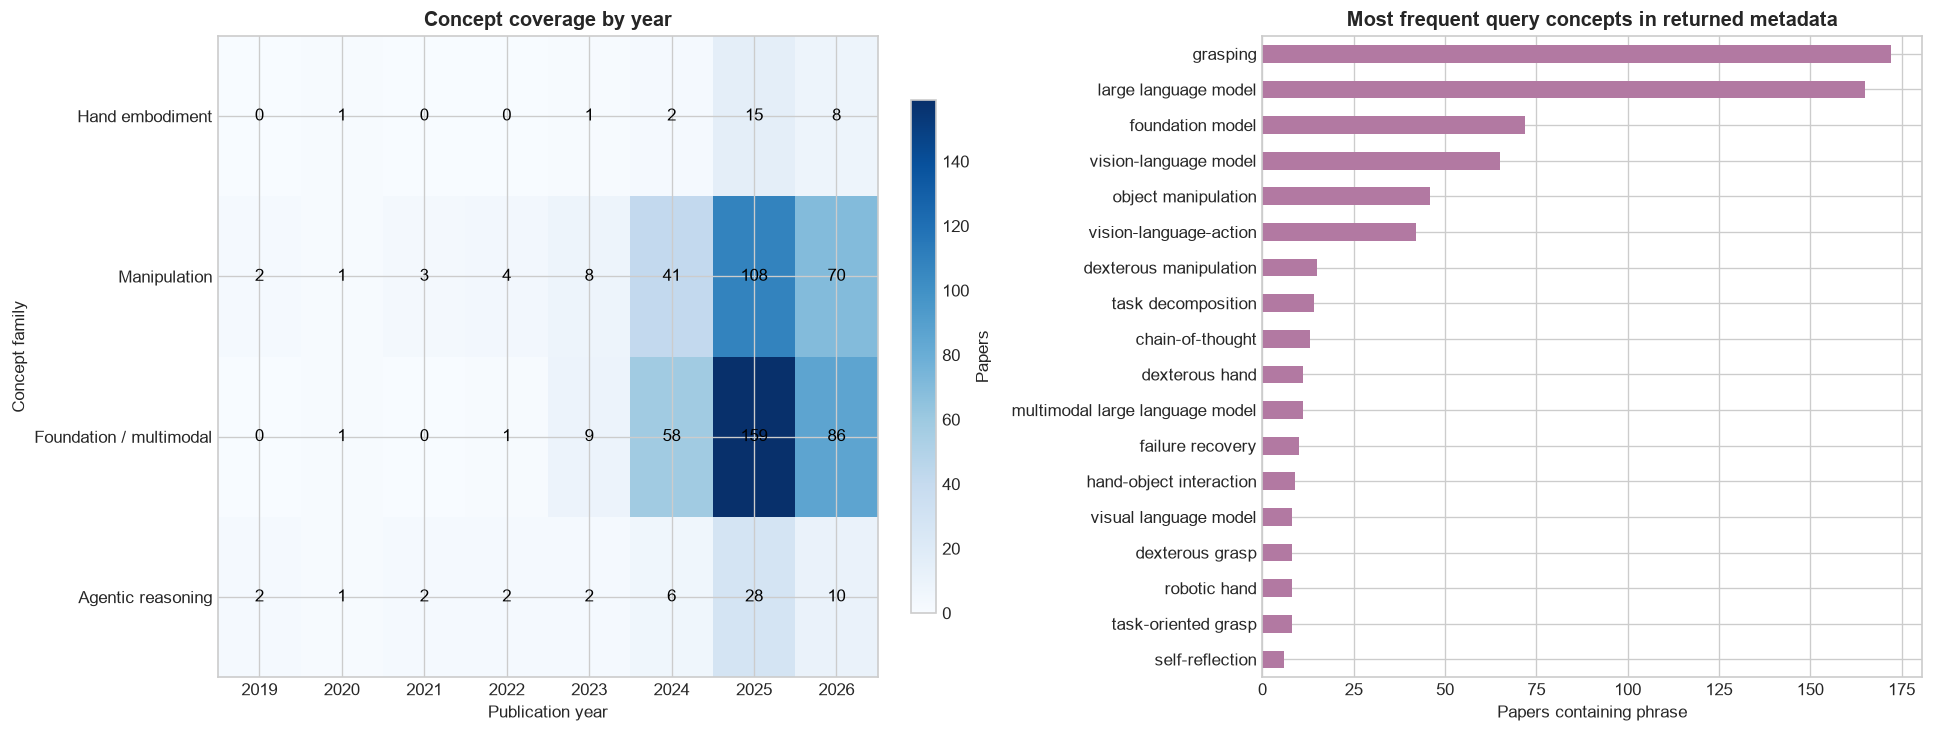

In [11]:
# Concept coverage over time and the phrases most often visible in metadata.
concept_columns = {
    "Hand embodiment": "hand_embodiment",
    "Manipulation": "manipulation",
    "Foundation / multimodal": "foundation_multimodal",
    "Agentic reasoning": "agentic_reasoning",
}
year_concepts = (
    viz_df.dropna(subset=["year"])
    .assign(year=lambda frame: frame["year"].astype(int))
    .groupby("year")[[*concept_columns.values()]]
    .sum()
    .rename(columns={value: key for key, value in concept_columns.items()})
)

term_counts = Counter()
for concept in concept_terms:
    column = concept.lower().replace(" / ", "_").replace(" ", "_") + "_terms"
    for terms in viz_df[column]:
        term_counts.update(terms)
top_terms = pd.Series(dict(term_counts.most_common(18))).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
image = axes[0].imshow(year_concepts.T, aspect="auto", cmap="Blues")
axes[0].set_title("Concept coverage by year")
axes[0].set_xlabel("Publication year")
axes[0].set_ylabel("Concept family")
axes[0].set_xticks(range(len(year_concepts.index)), year_concepts.index)
axes[0].set_yticks(range(len(year_concepts.columns)), year_concepts.columns)
for row in range(year_concepts.shape[1]):
    for col in range(year_concepts.shape[0]):
        value = int(year_concepts.iloc[col, row])
        axes[0].text(col, row, value, ha="center", va="center", color="black")
fig.colorbar(image, ax=axes[0], label="Papers", shrink=0.8)

top_terms.plot.barh(ax=axes[1], color="#B279A2")
axes[1].set(title="Most frequent query concepts in returned metadata", xlabel="Papers containing phrase", ylabel="")
plt.show()

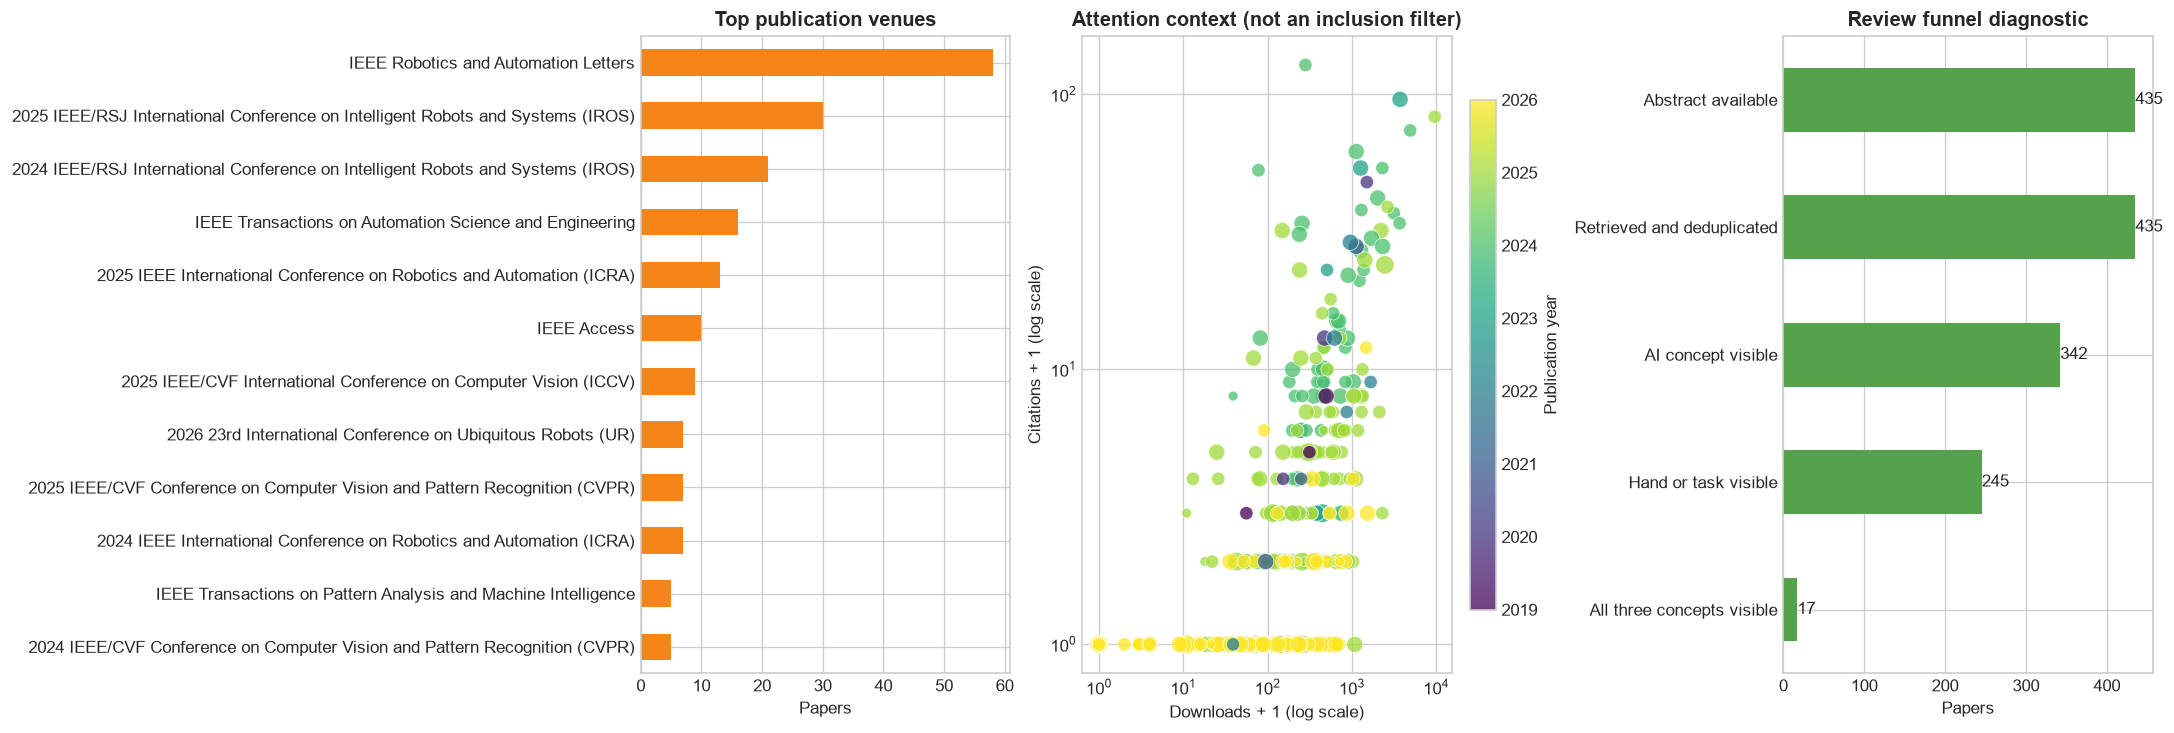

In [12]:
# Venue concentration, citation/download context, and a non-exclusionary review funnel.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

venues = viz_df.get("publication_title", pd.Series(dtype=str)).fillna("Unknown").replace("", "Unknown")
venues.value_counts().head(12).sort_values().plot.barh(ax=axes[0], color="#F58518")
axes[0].set(title="Top publication venues", xlabel="Papers", ylabel="")

scatter = axes[1].scatter(
    viz_df["downloads"] + 1,
    viz_df["citations"] + 1,
    c=viz_df["year"].fillna(viz_df["year"].min()),
    s=35 + 30 * viz_df["scope_score"],
    cmap="viridis", alpha=0.75, edgecolor="white", linewidth=0.5,
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set(title="Attention context (not an inclusion filter)", xlabel="Downloads + 1 (log scale)", ylabel="Citations + 1 (log scale)")
fig.colorbar(scatter, ax=axes[1], label="Publication year", shrink=0.8)

funnel = pd.Series({
    "Retrieved and deduplicated": len(viz_df),
    "Abstract available": viz_df["abstract"].str.strip().ne("").sum(),
    "AI concept visible": viz_df["ai_visible"].sum(),
    "Hand or task visible": (viz_df["hand_embodiment"] | viz_df["manipulation"]).sum(),
    "All three concepts visible": viz_df["scope_score"].eq(3).sum(),
}).sort_values()
funnel.plot.barh(ax=axes[2], color="#54A24B")
axes[2].set(title="Review funnel diagnostic", xlabel="Papers", ylabel="")
for patch in axes[2].patches:
    axes[2].text(patch.get_width() + 0.3, patch.get_y() + patch.get_height() / 2, int(patch.get_width()), va="center")

plt.show()